In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/sales_smoothing_datset.csv")
df.head()

,Month,Sales
0,2023-01,120
1,2023-02,165
2,2023-03,110
3,2023-04,190
4,2023-05,145


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   20 non-null     object
 1   Sales   20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


In [5]:
#Convert month into datetime

df["Month"] = pd.to_datetime(df["Month"])

#Set month as Index
df.set_index("Month", inplace=True)

#Sort Index
df.sort_index()
df.head()

,Sales
Month,
2023-01-01,120
2023-02-01,165
2023-03-01,110
2023-04-01,190
2023-05-01,145


In [6]:
#A 3month SMA calculates the average of the latest three observations.
df["SMA_3"] = df["Sales"].rolling(window=3).mean()
df.head()

,Sales,SMA_3
Month,,
2023-01-01,120,NaN
2023-02-01,165,NaN
2023-03-01,110,131.666667
2023-04-01,190,155.000000
2023-05-01,145,148.333333


In [7]:
add_one = lambda x: x+1
add_one(4)

5

In [10]:
#def add_one_value(x):

In [16]:
weights=np.array([2,3,4])

# adding new column to the dataframe with weighted moving average
df["WMA_3"] = (

 df['Sales']

 .rolling(window=3)

 .apply(lambda x: np.dot(x, weights)/weights.sum(), raw=True)

)

In [17]:
#Exponential Moving Average (EMA)

#Using a = 0.30
#adjust = False => Recursive Calculation
df["EMA"] = df["Sales"].ewm(alpha = 0.3, adjust = False).mean()

df.head()

,Sales,SMA_3,EMA,WMA_3
Month,,,,
2023-01-01,120,NaN,120.0000,NaN
2023-02-01,165,NaN,133.5000,NaN
2023-03-01,110,131.666667,126.4500,130.555556
2023-04-01,190,155.000000,145.5150,157.777778
2023-05-01,145,148.333333,145.3605,152.222222


<function matplotlib.pyplot.show(close=None, block=None)>

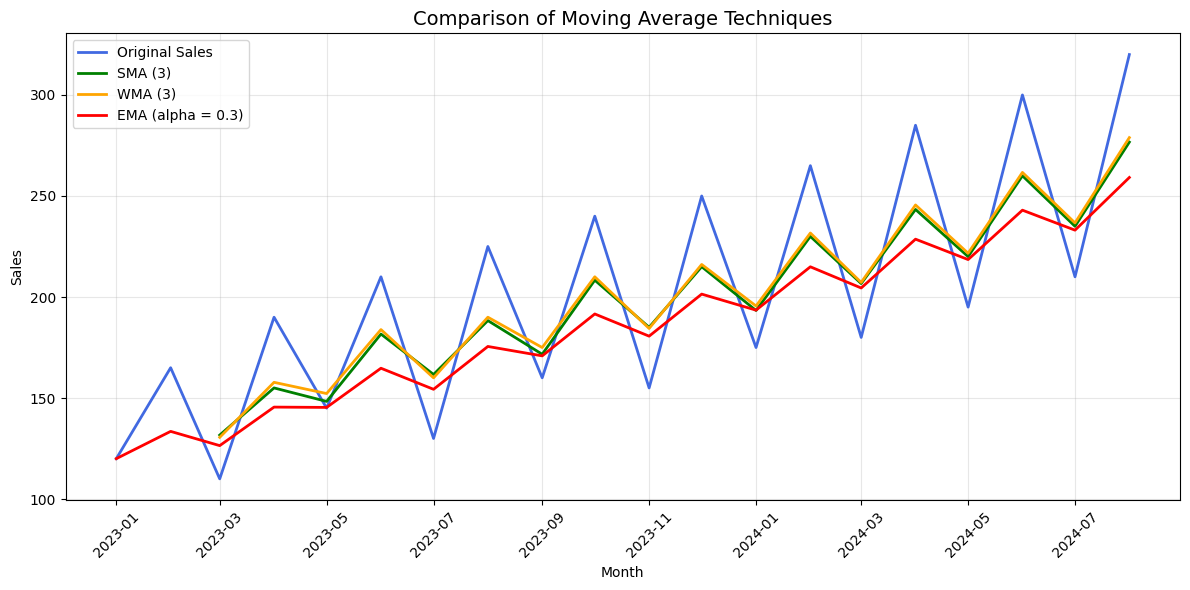

In [19]:
plt.figure(figsize = (12,6))
plt.plot(df.index, df["Sales"], color = "royalblue", linewidth = 2, label = "Original Sales")
plt.plot(df.index, df["SMA_3"], color = "green", linewidth = 2, label = "SMA (3)")
plt.plot(df.index, df["WMA_3"], color = "orange", linewidth = 2, label = "WMA (3)")
plt.plot(df.index, df["EMA"], color = "red", linewidth = 2, label = "EMA (alpha = 0.3)")

plt.title("Comparison of Moving Average Techniques", fontsize = 14)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(alpha = 0.3)
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()

plt.show

In [20]:
df["SMA_3"] = df["Sales"].rolling(window = 3).mean()
df.head()

,Sales,SMA_3,EMA,WMA_3
Month,,,,
2023-01-01,120,NaN,120.0000,NaN
2023-02-01,165,NaN,133.5000,NaN
2023-03-01,110,131.666667,126.4500,130.555556
2023-04-01,190,155.000000,145.5150,157.777778
2023-05-01,145,148.333333,145.3605,152.222222


In [21]:
df["SMA_4"] = df["Sales"].rolling(window = 4).mean()
df.head()

,Sales,SMA_3,EMA,WMA_3,SMA_4
Month,,,,,
2023-01-01,120,NaN,120.0000,NaN,NaN
2023-02-01,165,NaN,133.5000,NaN,NaN
2023-03-01,110,131.666667,126.4500,130.555556,NaN
2023-04-01,190,155.000000,145.5150,157.777778,146.25
2023-05-01,145,148.333333,145.3605,152.222222,152.50


In [22]:
df["SMA_5"] = df["Sales"].rolling(window = 5).mean()
df.head()

,Sales,SMA_3,EMA,WMA_3,SMA_4,SMA_5
Month,,,,,,
2023-01-01,120,NaN,120.0000,NaN,NaN,NaN
2023-02-01,165,NaN,133.5000,NaN,NaN,NaN
2023-03-01,110,131.666667,126.4500,130.555556,NaN,NaN
2023-04-01,190,155.000000,145.5150,157.777778,146.25,NaN
2023-05-01,145,148.333333,145.3605,152.222222,152.50,146.0


<function matplotlib.pyplot.show(close=None, block=None)>

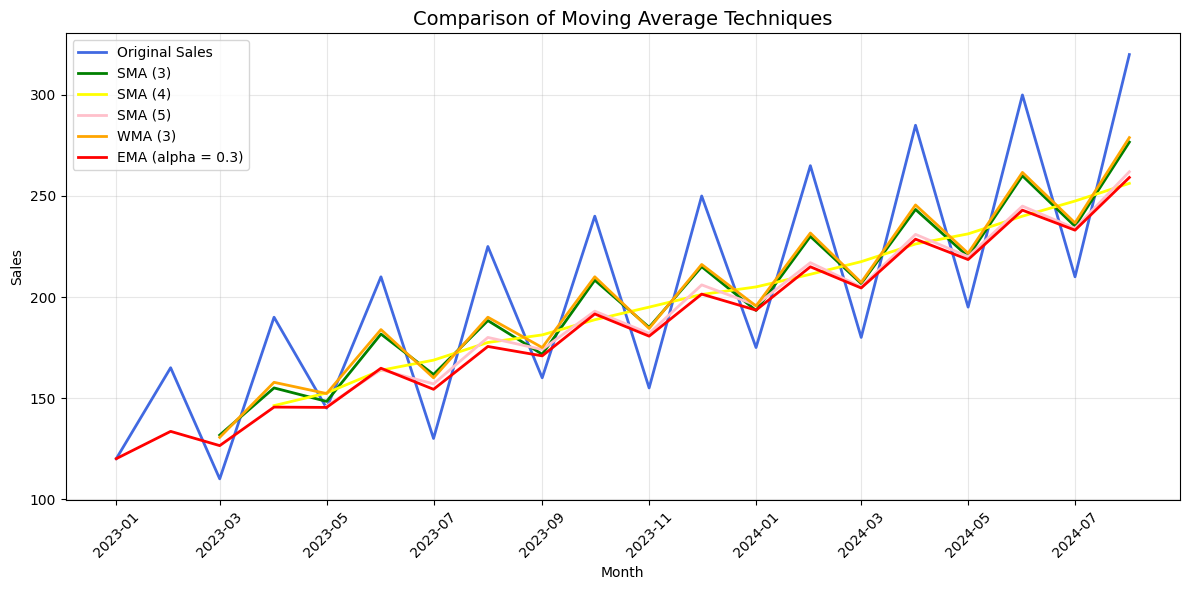

In [23]:
plt.figure(figsize = (12,6))
plt.plot(df.index, df["Sales"], color = "royalblue", linewidth = 2, label = "Original Sales")
plt.plot(df.index, df["SMA_3"], color = "green", linewidth = 2, label = "SMA (3)")
plt.plot(df.index, df["SMA_4"], color = "yellow", linewidth = 2, label = "SMA (4)")
plt.plot(df.index, df["SMA_5"], color = "pink", linewidth = 2, label = "SMA (5)")
plt.plot(df.index, df["WMA_3"], color = "orange", linewidth = 2, label = "WMA (3)")
plt.plot(df.index, df["EMA"], color = "red", linewidth = 2, label = "EMA (alpha = 0.3)")

plt.title("Comparison of Moving Average Techniques", fontsize = 14)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(alpha = 0.3)
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()

plt.show